In [18]:
# Sample Data

import pandas as pd
import Log_metrics_extract as lm
import os

# Create a dummy dataframe structure to simulate the actual CSV
columns = [
    "iteration",
    "layer_1_channels", "layer_1_filter", "layer_1_padding", "layer_1_param_count",
    "layer_2_channels", "layer_2_filter", "layer_2_padding", "layer_2_param_count",
    "layer_3_channel", "layer_3_filter", "layer_3_padding", "layer_3_param_count",
    "total_param_count"
]

# Generate a small sample to test the plotting functions
df = pd.DataFrame({
    "iteration": range(10),
    "layer_1_channels": [16, 32, 16, 16, 64, 64, 32, 64, 16, 16],
    "layer_1_filter": [3, 5, 3, 3, 5, 5, 7, 3, 3, 7],
    "layer_1_padding": [1, 2, 1, 1, 2, 0, 0, 1, 2, 1],
    "layer_1_param_count": [100]*10,
    "layer_2_channels": [64, 64, 64, 32, 64, 32, 64, 32, 64, 32],
    "layer_2_filter": [3, 3, 5, 3, 5, 5, 7, 3, 3, 7],
    "layer_2_padding": [1, 1, 2, 1, 2, 0, 0, 1, 2, 1],
    "layer_2_param_count": [200]*10,
    "layer_3_channels": [128, 64, 64, 128, 64, 128, 64, 128, 64, 128],
    "layer_3_filter": [3, 3, 5, 3, 5, 5, 7, 3, 3, 7],
    "layer_3_padding": [1, 1, 2, 1, 2, 0, 0, 1, 2, 1],
    "layer_3_param_count": [300]*10,
    "total_param_count": [600]*10
})

df.head()


,iteration,layer_1_channels,layer_1_filter,layer_1_padding,layer_1_param_count,layer_2_channels,layer_2_filter,layer_2_padding,layer_2_param_count,layer_3_channel,layer_3_filter,layer_3_padding,layer_3_param_count,total_param_count
0,0,16,3,1,100,64,3,1,200,128,3,1,300,600
1,1,32,5,2,100,64,3,1,200,64,3,1,300,600
2,2,16,3,1,100,64,5,2,200,64,5,2,300,600
3,3,16,3,1,100,32,3,1,200,128,3,1,300,600
4,4,64,5,2,100,64,5,2,200,64,5,2,300,600


In [33]:
import matplotlib.pyplot as plt

def plot_token_distribution(df, include_layer1=True, use_sns=False, sns_palette="tab20c"):
    """
    Plot token distributions (channels, filter, padding) in a 1x3 subplot layout.

    Args:
        df (pd.DataFrame): DataFrame containing architecture logs.
        include_layer1 (bool): Whether to include layer 1 in the plots.
        use_sns (bool): Whether to use seaborn or matplotlib styles.
    """
    token_map = {
        "channels": ["layer_1_channels", "layer_2_channels", "layer_3_channels"],
        "filter": ["layer_1_filter", "layer_2_filter", "layer_3_filter"],
        "padding": ["layer_1_padding", "layer_2_padding", "layer_3_padding"]
    }

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    fig.suptitle("Experiment Token Distribution", fontsize=16)

    for i, token_type in enumerate(["channels", "filter", "padding"]):
        layers = token_map[token_type]
        if not include_layer1:
            layers = layers[1:]

        df_tokens = df[layers].copy()
        df_tokens.columns = [f"Layer {j+1 if include_layer1 else j+2}" for j in range(len(layers))]
        df_melted = df_tokens.melt(var_name="Layer", value_name="Token")

        token_counts = df_melted.groupby(["Layer", "Token"]).size().reset_index(name="Count")
        pivot = token_counts.pivot(index="Layer", columns="Token", values="Count").fillna(0)

        ax = axs[i]
        pivot.plot(kind="bar", stacked=True, ax=ax, colormap=sns_palette if use_sns else None)
        ax.set_title(f"{token_type.capitalize()} Token Distribution")
        ax.set_ylabel("Count")
        ax.set_xlabel("Layer")
        ax.set_xticklabels(pivot.index, rotation=0)
        ax.legend(title=token_type.capitalize(), bbox_to_anchor=(1.05, 1), loc="upper left")
        ax.grid(axis='y')

    plt.tight_layout()
    plt.show()


In [40]:
def generate_token_distribution_csv(experiment_name):
    log_file_dir = os.path.join("LogFiles", "TrainingLogs")
    log_output_dir = os.path.join("LogFiles", "Output")
    os.makedirs(log_file_dir, exist_ok=True)
    os.makedirs(log_output_dir, exist_ok=True)

    log_file_path = os.path.join(log_file_dir, f"{experiment_name}.log")
    log_output_path = os.path.join(log_output_dir, f"{experiment_name}_log.csv")

    if not os.path.exists(log_file_path):
        raise FileNotFoundError(f"Log file does not exist at : {log_file_path}")


    lm.parse_training_log(log_file_path, log_output_path)

In [45]:
experiment_name = "EXP_6_CIFAR"

generate_token_distribution_csv(experiment_name)

✅ Fixed padding captured and exported 500 models to LogFiles/Output/EXP_6_CIFAR_log.csv


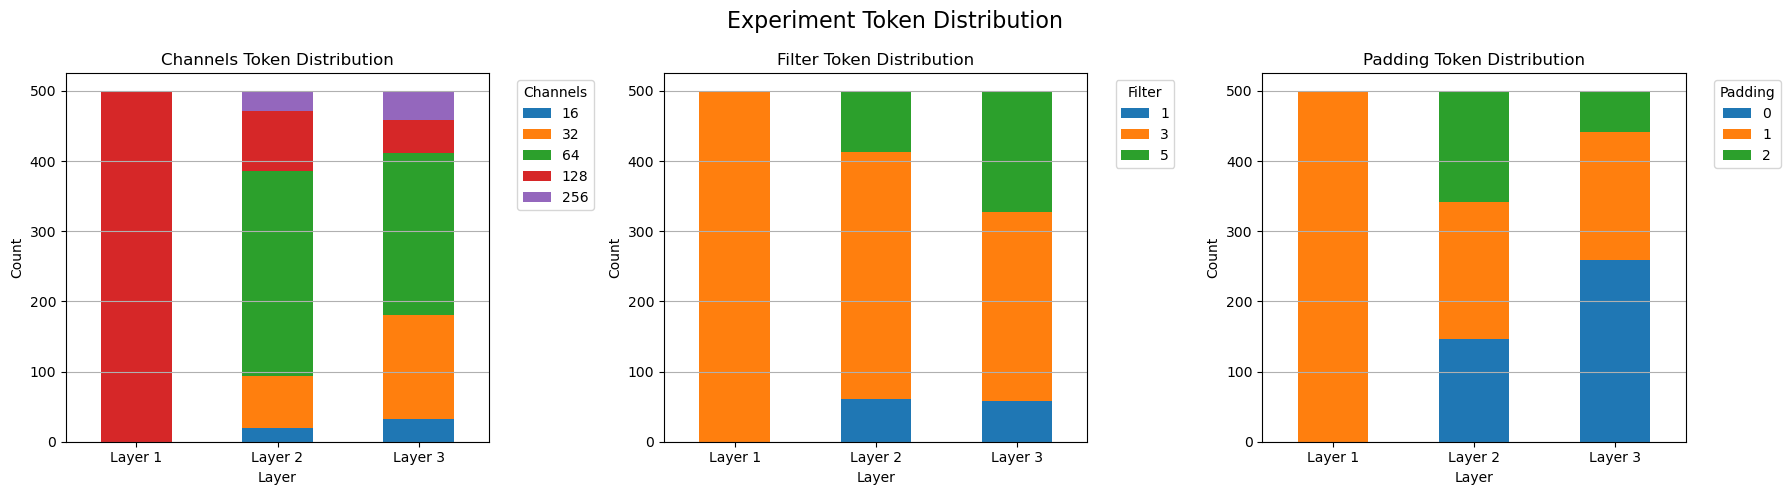

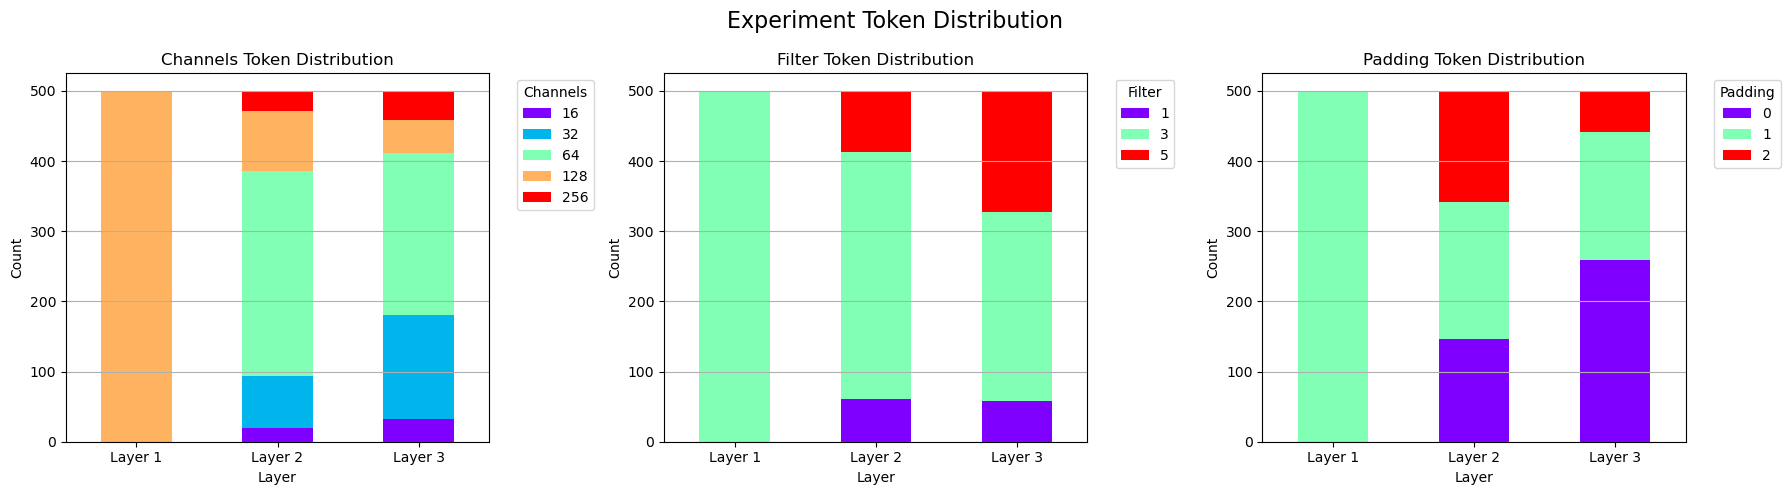

In [47]:
# Matplotlib version
path = os.path.join("LogFiles", "Output", f"{experiment_name}_log.csv")
df = pd.read_csv(path)


plot_token_distribution(df, include_layer1=True, use_sns=False)

# Seaborn version
plot_token_distribution(df, include_layer1=True, use_sns=True, sns_palette="rainbow")


In [52]:
experiment_name = "EXP_6_CIFAR10"
df = pd.read_csv(os.path.join("Results", "Controller", "CNN", f"{experiment_name}.csv"))
print(df.head())

df.describe()

   train_loss  val_loss  test_acc  train_time  policy_gradient  max_accuracy  \
0    0.642527  0.677846    0.7658   94.129953         0.081712        0.7658   
1    0.625208  0.640382    0.7826   64.795565         0.769014        0.7826   
2    0.810081  0.773788    0.7307   66.230641         0.631927        0.7826   
3    0.831395  0.779634    0.7293   63.859987         0.237514        0.7826   
4    0.700526  0.697938    0.7581   63.820858         0.563878        0.7826   

   baseline  
0  0.001219  
1  0.010584  
2  0.018929  
3  0.021818  
4  0.029931  


,train_loss,val_loss,test_acc,train_time,policy_gradient,max_accuracy,baseline
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.704474,0.677215,0.765384,61.850851,0.004803,0.811828,0.097031
std,0.083589,0.066696,0.024998,3.020462,0.153478,0.005265,0.015972
min,0.518543,0.553475,0.629100,58.534355,-0.648091,0.765800,0.001219
25%,0.646092,0.630811,0.751050,60.241490,-0.050738,0.811600,0.091286
50%,0.691313,0.664099,0.770500,60.830967,0.019744,0.815100,0.101679
75%,0.756210,0.717110,0.782600,62.406214,0.072308,0.815100,0.107042
max,1.097841,1.035432,0.815100,94.129953,0.769014,0.815100,0.117871


In [56]:
def compute_grouped_stats(df, step=50, metrics=None, stats=None):
    """
    Compute custom grouped statistics over row-index based brackets with labeled index ranges.

    Args:
        df (pd.DataFrame): DataFrame with metric columns.
        step (int): Grouping interval size, e.g., 50.
        metrics (list or None): Metric columns to compute. If None, use all columns.
        stats (list or None): Statistics to compute. Options: 'mean', 'std', 'min', 'max', '50%', etc.
                              If None, compute all available.

    Returns:
        pd.DataFrame: Grouped statistics indexed by range labels like '0-49', '50-99', etc.
    """
    if metrics is None:
        metrics = df.columns.tolist()
    if stats is None:
        stats = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']

    df = df.copy()
    df["row_index"] = df.index
    df["range_label"] = df["row_index"].apply(lambda x: f"{(x // step) * step}-{(x // step + 1) * step - 1}")

    grouped = df.groupby("range_label", sort=False)[metrics].describe()

    if isinstance(grouped.columns, pd.MultiIndex):
        grouped = grouped.loc[:, grouped.columns.get_level_values(1).isin(stats)]

    return grouped


# Example usage
grouped_result = compute_grouped_stats(df, step=50, metrics=["test_acc", "train_time"], stats=["mean", "std"])
grouped_result

test_acc           train_time          
                 mean       std       mean       std
range_label                                         
0-49         0.754944  0.033403  65.211339  5.999812
50-99        0.765864  0.029342  63.512239  3.864713
100-149      0.766268  0.026724  61.771484  2.096923
150-199      0.759716  0.025922  61.544825  1.877898
200-249      0.758964  0.026249  61.136107  1.742308
250-299      0.768060  0.023425  61.354258  1.791589
300-349      0.764010  0.021012  61.120550  1.602077
350-399      0.769524  0.022026  60.971053  1.529296
400-449      0.770244  0.016837  60.887601  1.058149
450-499      0.776248  0.013962  60.999057  1.882489